<a href="https://colab.research.google.com/github/Shrushti-2002/Movie-Rating-Prediction-with-Python/blob/main/Movie_Rating_Prediction_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [14]:
df = pd.read_csv("IMDb Movies India.csv", encoding="ISO-8859-1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [15]:
df = df.dropna(subset=["Rating"])

df["Genre"].fillna("Unknown", inplace=True)
df["Director"].fillna("Unknown", inplace=True)
df["Actor 1"].fillna("Unknown", inplace=True)
df["Actor 2"].fillna("Unknown", inplace=True)
df["Actor 3"].fillna("Unknown", inplace=True)

/tmp/ipython-input-1238195239.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Genre"].fillna("Unknown", inplace=True)
/tmp/ipython-input-1238195239.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [16]:
df["Year"] = df["Year"].str.extract(r'(\d{4})').astype(float)
df["Duration"] = df["Duration"].str.replace(" min", "", regex=True).astype(float)

In [17]:
label_cols = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
X = df[["Year", "Duration", "Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]]
y = df["Rating"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [21]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.9260208333333333
RMSE: 1.2002200943730565
R² Score: 0.22516631787069086


In [22]:
sample_movie = pd.DataFrame({
    "Year": [2023],
    "Duration": [140],
    "Genre": [df["Genre"].mean()],
    "Director": [df["Director"].mean()],
    "Actor 1": [df["Actor 1"].mean()],
    "Actor 2": [df["Actor 2"].mean()],
    "Actor 3": [df["Actor 3"].mean()]
})

predicted_rating = model.predict(sample_movie)
print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 5.5074999999999985


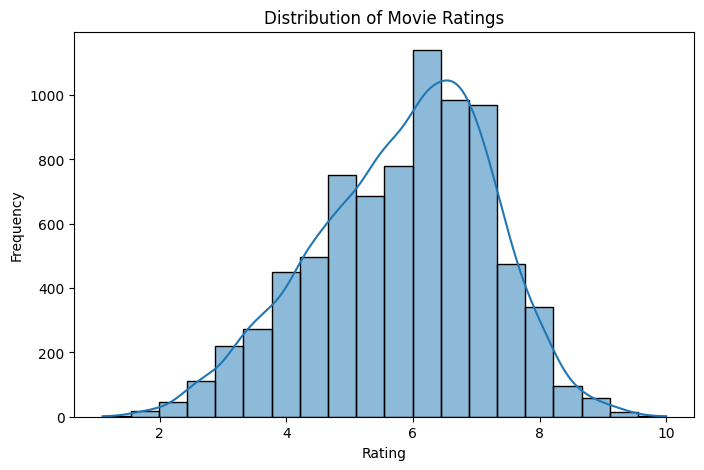

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

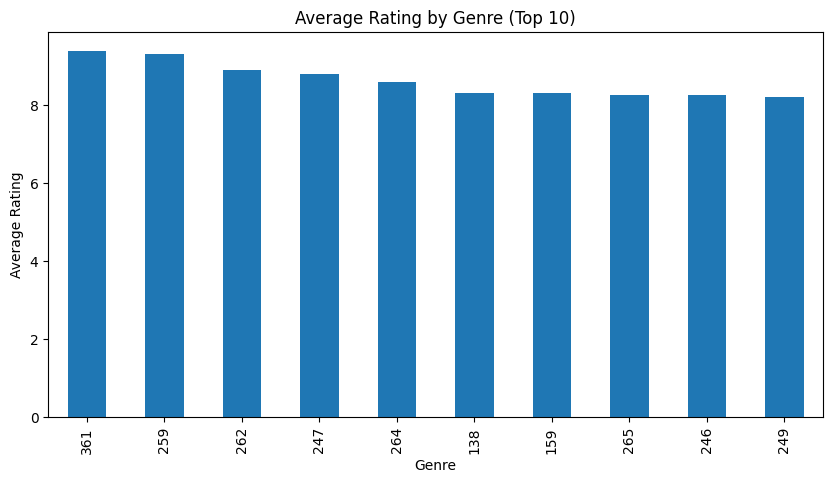

In [24]:
genre_rating = df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)[:10]

plt.figure(figsize=(10,5))
genre_rating.plot(kind="bar")
plt.title("Average Rating by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()

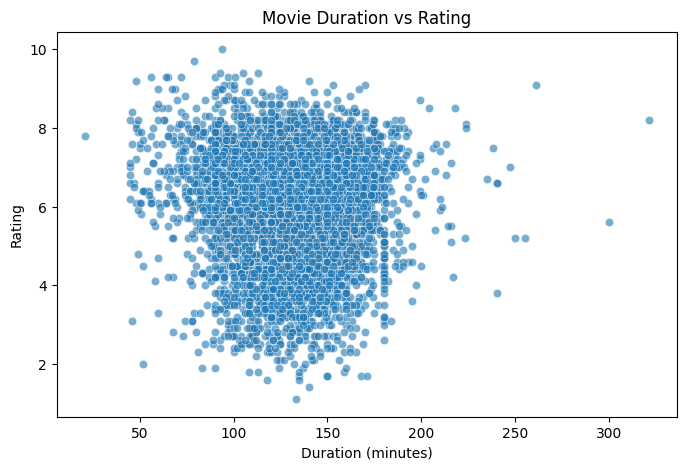

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Duration"], y=df["Rating"], alpha=0.6)
plt.title("Movie Duration vs Rating")
plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.show()

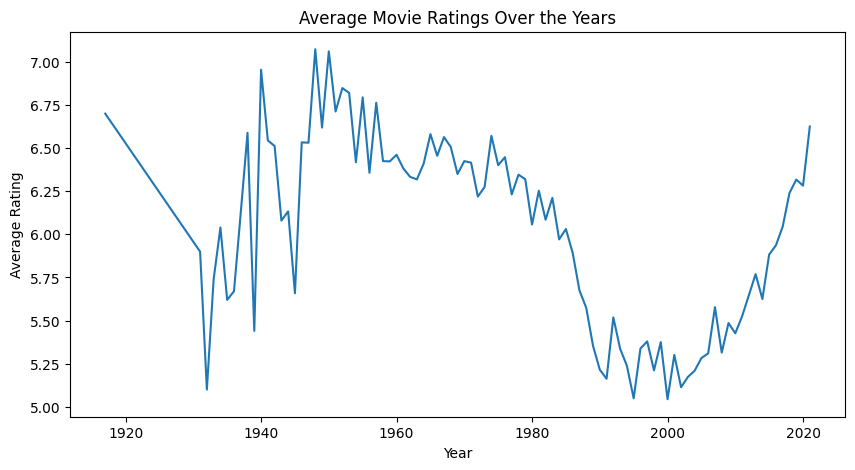

In [26]:
year_rating = df.groupby("Year")["Rating"].mean()

plt.figure(figsize=(10,5))
plt.plot(year_rating.index, year_rating.values)
plt.title("Average Movie Ratings Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

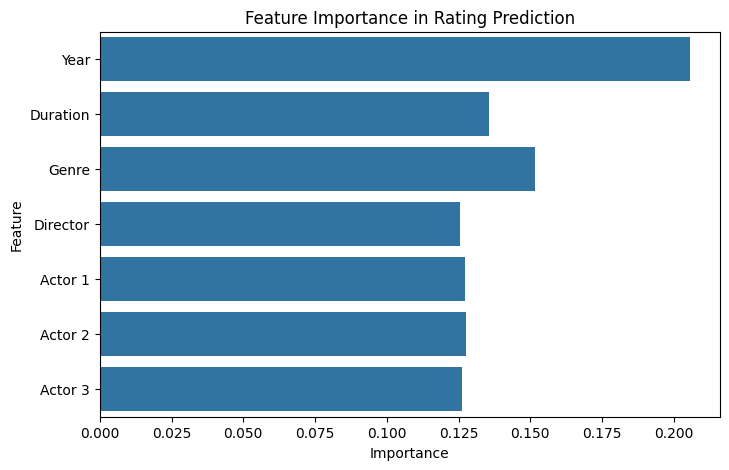

In [27]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance in Rating Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

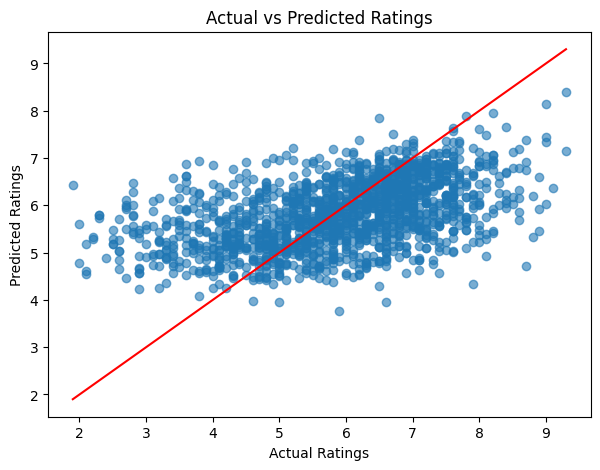

In [28]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.title("Actual vs Predicted Ratings")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.show()